<h1 style="font-family: 'Georgia', serif; text-align: center; font-weight: normal; margin-bottom: 0px;">
  <em>Coding Categorical Entropy Loss & Accuracy</em>
</h1>
<p style="text-align: center; font-family: 'Georgia', serif; color: gray; margin-top: 5px;">
  Full forward pass with loss and accuracy
</p>
<hr style="width: 50%; border: 1px solid #ddd;">

<center>
    <img src="Note-Images/loss.jpg">
</center>

# From Previous Forward Pass Code (look at 7)

In [ ]:
pip install nnfs

In [6]:
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
import numpy as np

In [8]:
X,y = spiral_data(samples = 200, classes=3)

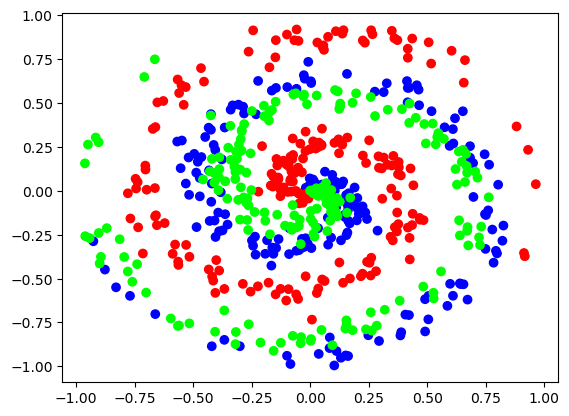

In [19]:
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'brg')
plt.show()

In [48]:
y_one_hot = np.eye(3)[y] # np.eye returns an identity matrix 
print(y_one_hot[:5,:])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [29]:
class Dense_Layer:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((n_neurons))
    def forward_pass(self,inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output        

In [14]:
class ReLU:
    def forward_pass(self, inputs):
        self.output = np.maximum(0, inputs)
        return self.output

In [16]:
class Softmax:
    def forward_pass(self, inputs):
        scaled = inputs - np.max(inputs, axis = 1, keepdims = True)
        exp_val = np.exp(scaled)
        self.output = exp_val / np.sum(exp_val, axis = 1, keepdims = True)
        return self.output
        

# Cross Entropy Loss


In [23]:
class Cross_entropy_loss:
    def forward_pass(self, inputs, y):
        clipped = np.clip(inputs, 1e-7, 1 - 1e-7) # we clip the values cause if the value is too high or too small it can result into inf/zero loss
        final = np.sum(clipped * y, axis = 1, keepdims = True)
        loss = - (np.log(final))
        self.output = np.mean(loss)
        return self.output
        

In [31]:
Layer1 = Dense_Layer(2,5)
Layer1_output = Layer1.forward_pass(X)

activation1 = ReLU()
activation1_output = activation1.forward_pass(Layer1_output)

Layer2 = Dense_Layer(activation1_output.shape[1], 3)
Layer2_output = Layer2.forward_pass(activation1_output)

activation2 = Softmax()
activation2_output = activation2.forward_pass(Layer2_output)

loss = Cross_entropy_loss()
final_loss = loss.forward_pass(activation2_output, y_one_hot)

print(final_loss)

1.098606724685158


# Accuracy

In [45]:
predictions = np.argmax(activation2_output, axis =1) # argmax returns the axis of max value and the reason we didnt do keepdims = True cause we wanted 1d array only otherwise it would have returned N x 1 matrix and there could have broadcasting issues.
y = np.argmax(y_one_hot, axis = 1)
accuracy = np.mean(predictions == y)
print(accuracy)

0.4066666666666667
